In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


# Loading the dataset

In [2]:
df = pd.read_csv('Advertising.csv')

# Descriptive Analytics
### 1. Data overview

In [3]:
print("Rows, columns:", df.shape)
print("Duplicated rows:", df.duplicated().sum())
print("\nColumn info:")
df.info()
print("\nMissing values:\n", df.isnull().sum())

Rows, columns: (200, 4)
Duplicated rows: 0

Column info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB

Missing values:
 TV           0
radio        0
newspaper    0
sales        0
dtype: int64


### 2. ummary Statistics

In [4]:
summary = df.describe().T
summary['range'] = df.max()- df.min()
summary['median'] = df.median()
summary['IQR'] = df.quantile(0.75) - df.quantile(0.25)
summary[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'range', 'median', 'IQR']]

,count,mean,std,min,25%,50%,75%,max,range,median,IQR
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4,295.7,149.75,144.450
radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6,49.6,22.90,26.550
newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0,113.7,25.75,32.350
sales,200.0,14.0225,5.217457,1.6,10.375,12.90,17.400,27.0,25.4,12.90,7.025


### 3. Distribution

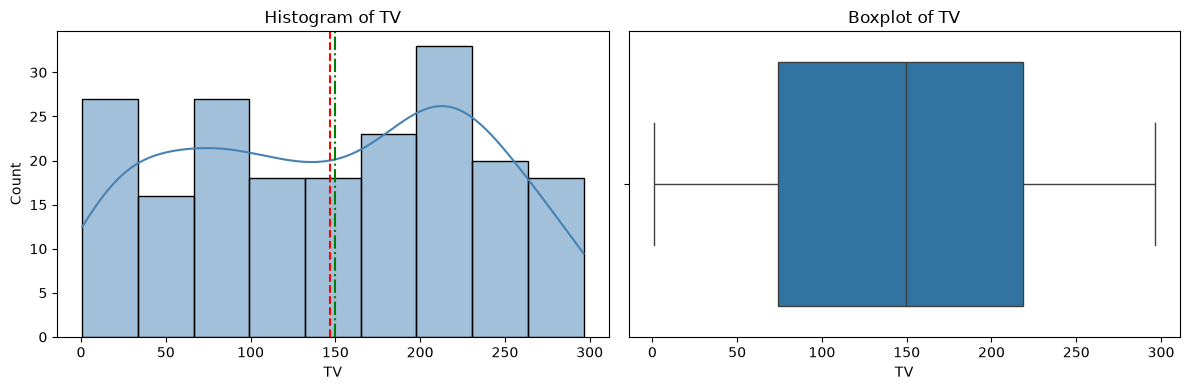

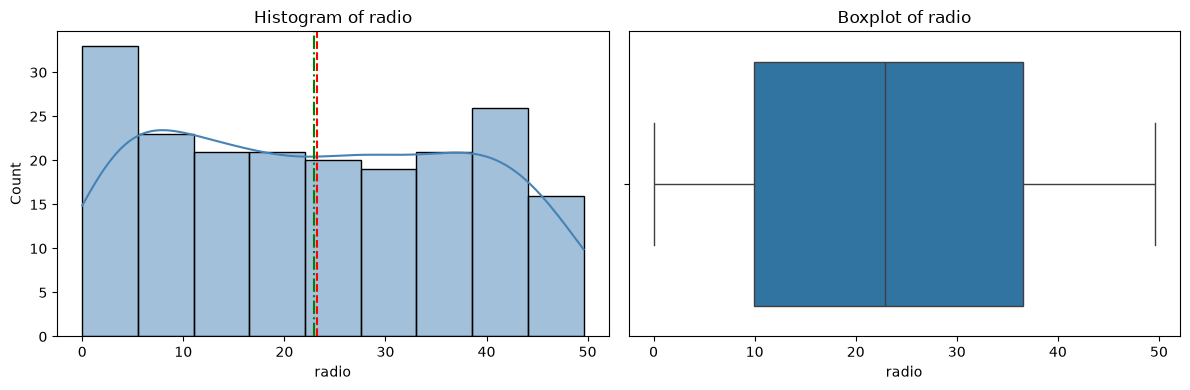

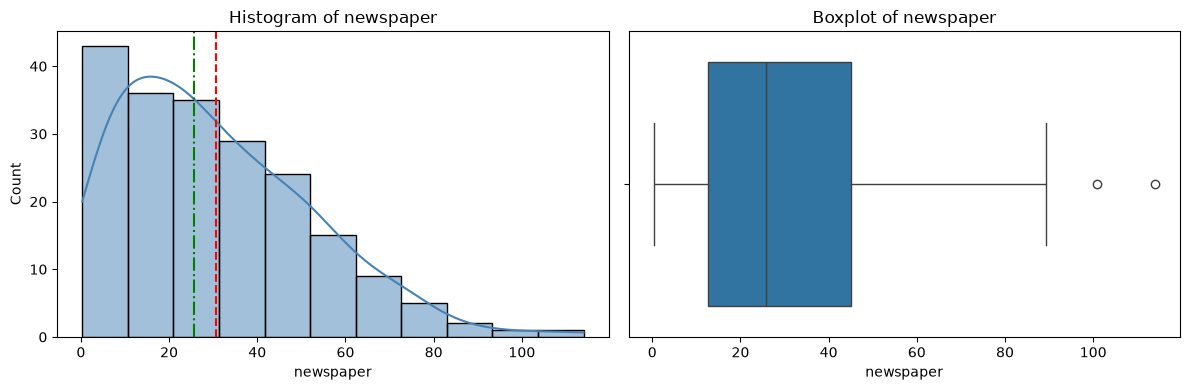

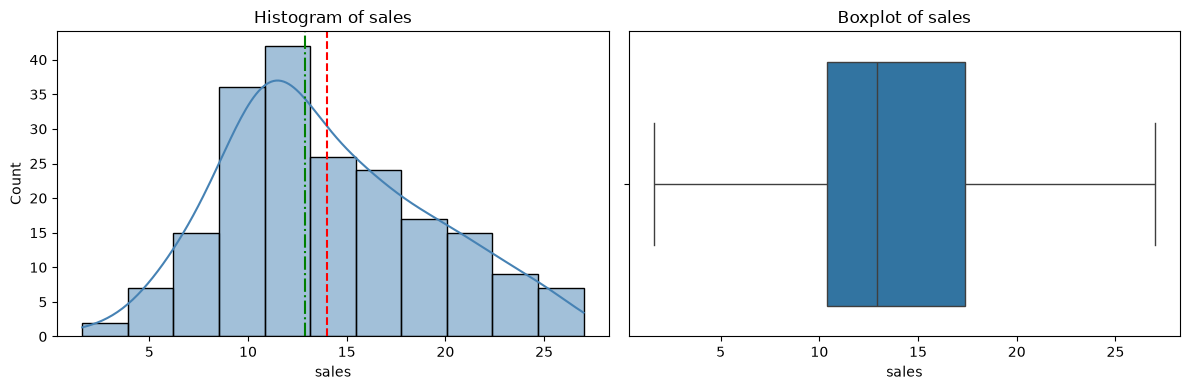

In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns
for i, col in enumerate(num_cols):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], kde=True, ax=axes[0], color="steelblue")
    axes[0].axvline(df[col].mean(), color="red", ls="--", label="mean")
    axes[0].axvline(df[col].median(), color="green", ls="-.", label="median")
    axes[0].set_title(f"Histogram of {col}")

    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

### 4. Correlation

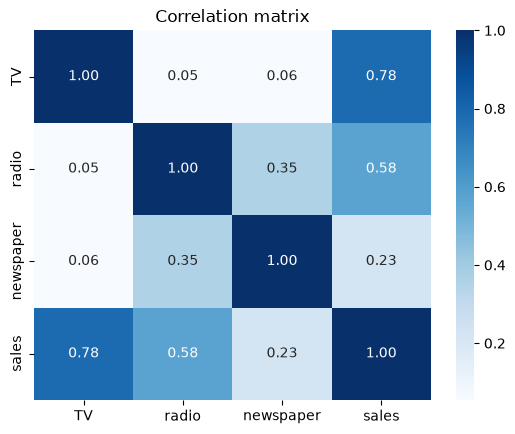

In [6]:
sns.heatmap(df.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation matrix") 
plt.show()

### 5. Relation between each channel and sales

<Figure size 800x600 with 0 Axes>

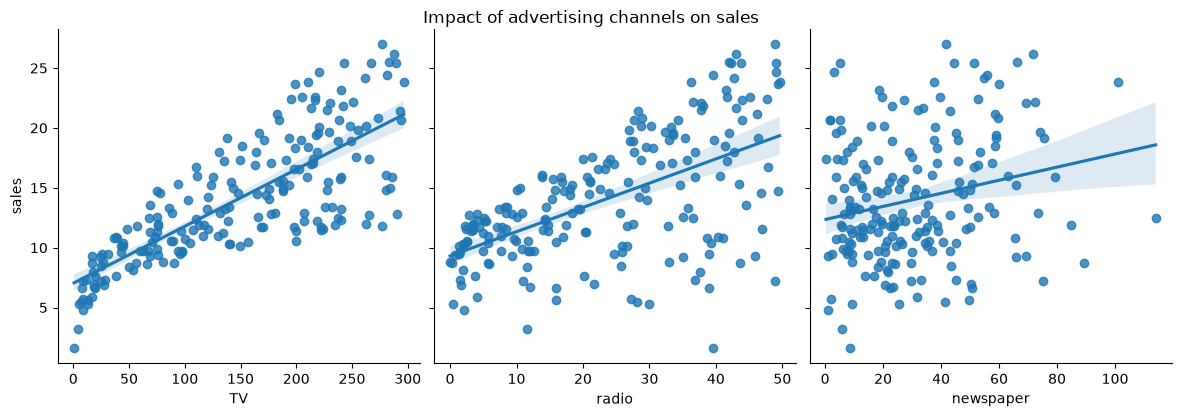

In [7]:
plt.figure(figsize=(8, 6))
sns.pairplot(df, x_vars=["TV", "radio", "newspaper"], y_vars="sales",
             height=4, aspect=1, kind="reg")
plt.suptitle("Impact of advertising channels on sales", y=1.02)
plt.show()

# Prepare Data

In [8]:
X = np.asarray(df[['TV']])
Y = np.asarray(df['sales'])

### 1. split data

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])

Train: 160 | Test: 40


# Simple Linear Regression

In [10]:

SR = LinearRegression().fit(X_train, Y_train)
Y_pred = SR.predict(X_test)
slope, intercept = SR.coef_[0], SR.intercept_
print(f"Equation: sales = {intercept:.3f} + {slope:.4f} x TV")

Equation: sales = 7.120 + 0.0465 x TV


### 1. model metrics 

In [11]:
r2 = r2_score(Y_test, Y_pred)
mse = mean_absolute_error(Y_test, Y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
print(f"R-squared (R^2): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

R-squared (R^2): 0.6767
Mean Absolute Error (MAE): 2.4444
Root Mean Squared Error (RMSE): 3.1945


# Visualisation

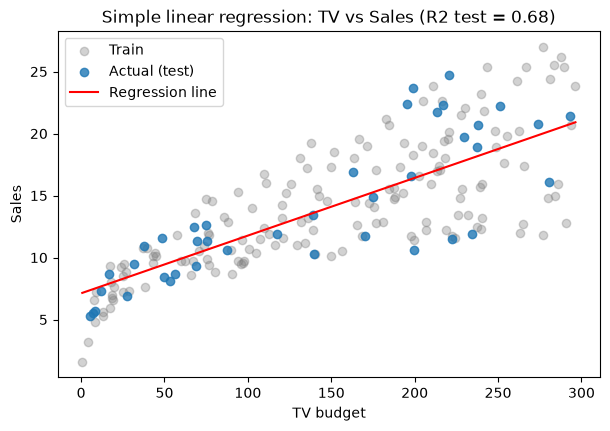

In [12]:
plt.figure(figsize=(7, 4.5))

plt.scatter(X_train, Y_train, alpha=0.35, color="gray", label="Train")

plt.scatter(X_test, Y_test, alpha=0.8, label="Actual (test)")



tv_grid = np.linspace(X[:, 0].min(), X[:, 0].max(), 100).reshape(-1, 1)

plt.plot(tv_grid[:, 0], SR.predict(tv_grid), color="red", label="Regression line")



plt.xlabel("TV budget"); plt.ylabel("Sales")

plt.title(f"Simple linear regression: TV vs Sales (R2 test = {r2:.2f})")

plt.legend(); plt.show()

# Residual Analysis

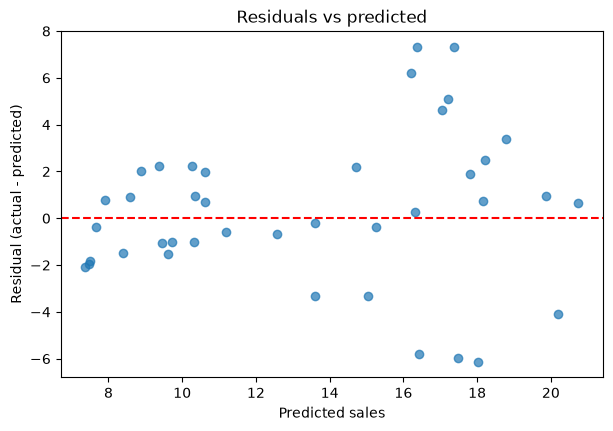

In [13]:
residuals = Y_test - Y_pred

plt.figure(figsize=(7, 4.5))
plt.scatter(Y_pred, residuals, alpha=0.7)
plt.axhline(0, color="red", ls="--")
plt.xlabel("Predicted sales"); plt.ylabel("Residual (actual - predicted)")
plt.title("Residuals vs predicted")
plt.show()